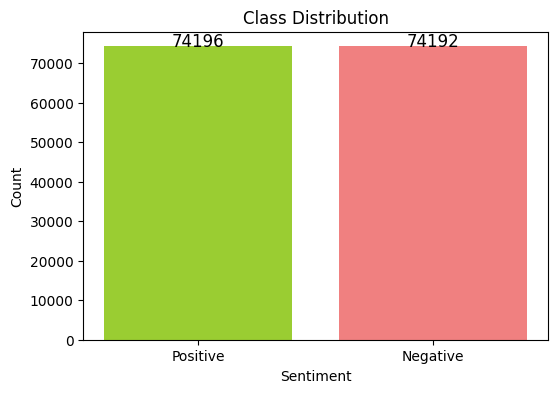

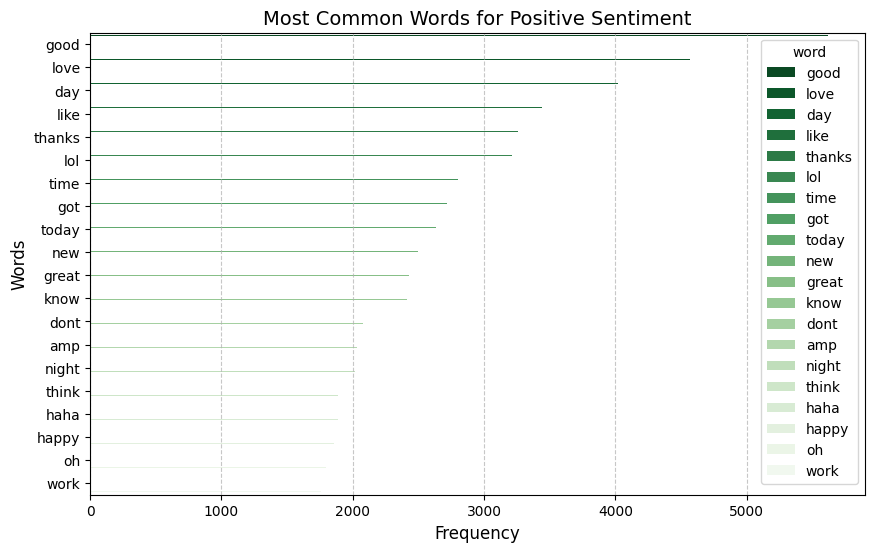

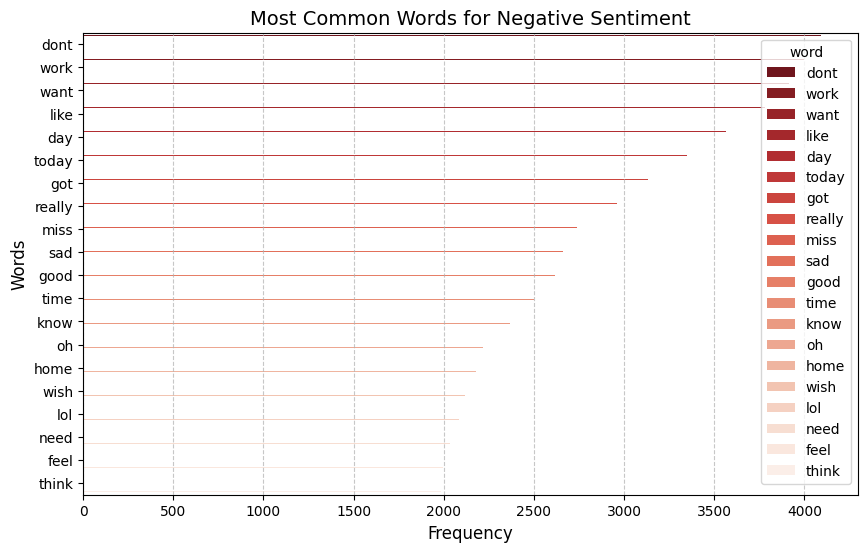

[==================================================] 100.0% 758.5/758.5MB downloaded


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch  1: Train Loss = 0.52730, Val Loss = 0.47762, Val Accuracy = 0.76941
Epoch  2: Train Loss = 0.49238, Val Loss = 0.47082, Val Accuracy = 0.77158
Epoch  3: Train Loss = 0.48407, Val Loss = 0.46719, Val Accuracy = 0.77363
Epoch  4: Train Loss = 0.47710, Val Loss = 0.46350, Val Accuracy = 0.77708
Epoch  5: Train Loss = 0.47261, Val Loss = 0.46268, Val Accuracy = 0.77701
Epoch  6: Train Loss = 0.46692, Val Loss = 0.45996, Val Accuracy = 0.77932
Epoch  7: Train Loss = 0.46241, Val Loss = 0.45878, Val Accuracy = 0.77998
Epoch  8: Train Loss = 0.45896, Val Loss = 0.45811, Val Accuracy = 0.78019
Epoch  9: Train Loss = 0.45525, Val Loss = 0.45809, Val Accuracy = 0.78095
Epoch 10: Train Loss = 0.45052, Val Loss = 0.45704, Val Accuracy = 0.78059
Epoch 11: Train Loss = 0.44711, Val Loss = 0.45652, Val Accuracy = 0.78281
Epoch 12: Train Loss = 0.44471, Val Loss = 0.45613, Val Accuracy = 0.78328
Epoch 13: Train Loss = 0.44107, Val Loss = 0.45794, Val Accuracy = 0.78198
Epoch 14: Train Loss = 0.

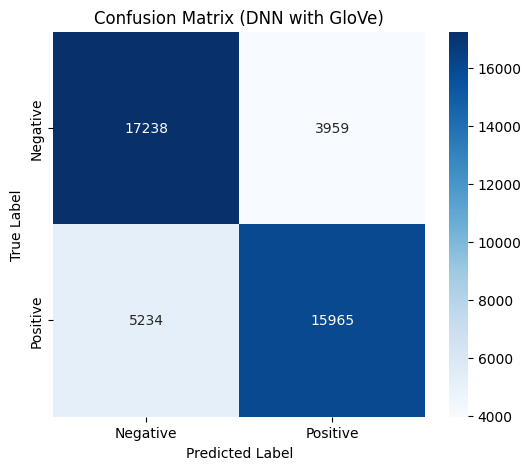

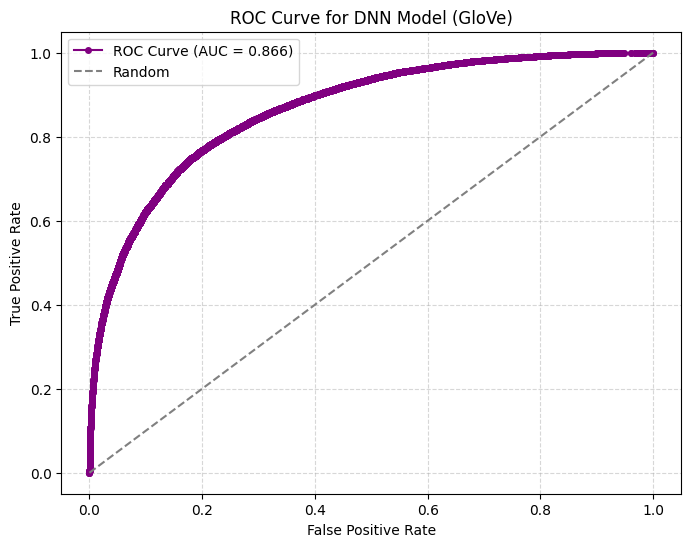

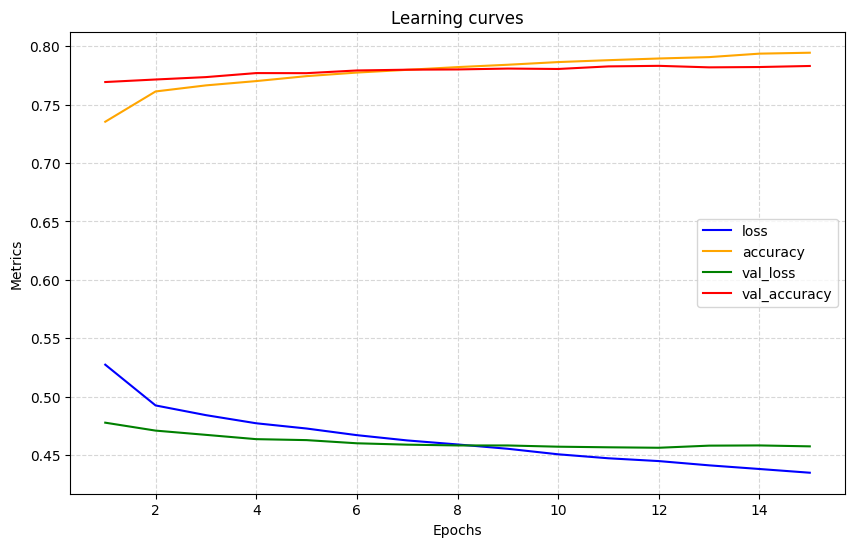

In [1]:
# Import basic libraries
import pandas as pd
import numpy as np
import re
import string
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import learning_curve
from matplotlib import pyplot as plt
import emoji
from collections import Counter
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
import torch
import torch.nn as nn
import gensim.downloader as api
from torch.optim.lr_scheduler import ReduceLROnPlateau
from gensim.models import KeyedVectors
import random
import os

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

# Load datasets
train_dataset = pd.read_csv("/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/train_dataset.csv")
validation_dataset = pd.read_csv("/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/val_dataset.csv")
test_dataset = pd.read_csv("/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/test_dataset.csv")

stopwords_to_remove = {"just", "im", "the", "going", "am", "are", "or", "of", "and"}

# Define text preprocessing function
def preprocess_text(text):
    if isinstance(text, str):  # Ensure input is a string
        
        text = text.lower() #Convert to lowercase

        #Remove URLs
        text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)

        #Remove hashtags and @s
        text = re.sub(r"@\w+|#\w+", "", text)

        #Remove punctuation
        text = re.sub(r"[^a-zA-Z0-9\s?!]", "", text)\

        #Correct the spelling mistakes
        text = re.sub(r"\b(luv)\b", "love", text)
        text = re.sub(r"\b(amzing)\b", "amazing", text)
        text = re.sub(r"\b(terible)\b", "terrible", text)
        text = re.sub(r"\b(excelent)\b", "excellent", text)
        text = re.sub(r"\b(perfonmence)\b", "performance", text)
        text = re.sub(r"\b(gud)\b", "good", text)
        text = re.sub(r"\b(vry)\b", "very", text)
        text = re.sub(r"\b(fntstic)\b", "fantastic", text)
        text = re.sub(r"\b(gr8)\b", "great", text)
        text = re.sub(r"\b(horrble)\b", "horrible", text)
        text = re.sub(r"\b(wanna)\b", "want to", text)
        text = re.sub(r"\b(gonna)\b", "going to", text)
        text = re.sub(r"\b(str8)\b", "straight", text)
        text = re.sub(r"\b(2night)\b", "tonight", text)
        text = re.sub(r"\b(thru)\b", "through", text)


        
        #If more than 3 characters --> Convert to 3 characters (e.g. heyyyyy --> heyyy)
        text = re.sub(r"(.)\1{2,}", r"\1", text)

        #Remove specific words (they are the most common words found in EDA for both positive and negative instances)
        
        words = text.split()
        text = " ".join([word for word in words if word not in stopwords_to_remove])
    
    return text

#Function to get the average of word2vec embeddings
def get_average_word2vec_embeddings(texts, model):
    embeddings = []
    for doc in texts:
        words = doc.split()
        valid_vectors = [model[word] for word in words if word in model]
        if valid_vectors:
            avg_vec = np.mean(valid_vectors, axis=0)
        else:
            avg_vec = np.zeros(200) #300 is the dimension of the vectors for google news
        embeddings.append(avg_vec)
    return np.array(embeddings)

# Apply preprocessing to dataset text columns
train_dataset["Text"] = train_dataset["Text"].apply(preprocess_text)
validation_dataset["Text"] = validation_dataset["Text"].apply(preprocess_text)
test_dataset["Text"] = test_dataset["Text"].apply(preprocess_text)

#Split dataset
X_train = train_dataset["Text"]
y_train = train_dataset["Label"]
X_validation = validation_dataset["Text"]
y_validation = validation_dataset["Label"]
X_test = test_dataset["Text"]

#Split datasets into positives and negatives
positive_dataset = train_dataset[train_dataset["Label"] == 1].copy()
negative_dataset = train_dataset[train_dataset["Label"] == 0].copy()

#EDA 1 - Count how many positive and negative instances are there
class_counts = train_dataset["Label"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values, color=["lightcoral", "yellowgreen"])
plt.xticks(class_counts.index, ["Negative", "Positive"])
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Class Distribution")

for i, v in enumerate(class_counts.values):
    plt.text(i, v + 10, str(v), ha="center", fontsize=12)
plt.show()



#EDA 2 - Most common words for positive and negative instances seperately
vectorizer = CountVectorizer(stop_words='english')

#For positives
X_counts_positive = vectorizer.fit_transform(positive_dataset["Text"])
word_freq_positive = dict(zip(vectorizer.get_feature_names_out(), np.asarray(X_counts_positive.sum(axis=0)).ravel()))
word_freq_sorted_positive = sorted(word_freq_positive.items(), key=lambda x: x[1], reverse=True)[:20]

plt.figure(figsize=(10, 6))
pos_word_df = pd.DataFrame(word_freq_sorted_positive, columns=['word', 'count'])
sns.barplot(y='word', x='count', data=pos_word_df, hue="word", palette="Greens_r")
plt.title("Most Common Words for Positive Sentiment", fontsize=14)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Words", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#For negatives
X_counts_negative = vectorizer.fit_transform(negative_dataset["Text"])
word_freq_negative = dict(zip(vectorizer.get_feature_names_out(), np.asarray(X_counts_negative.sum(axis=0)).ravel()))
word_freq_sorted_negative = sorted(word_freq_negative.items(), key=lambda x: x[1], reverse=True)[:20]

plt.figure(figsize=(10, 6))
neg_word_df = pd.DataFrame(word_freq_sorted_negative, columns=['word', 'count'])
sns.barplot(y='word', x='count', data=neg_word_df, hue="word", palette="Reds_r")
plt.title("Most Common Words for Negative Sentiment", fontsize=14)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Words", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#Load model
word2vec_model = api.load("glove-twitter-200")


#Get average of the vectors of the words as said in the class forum
X_train_average = get_average_word2vec_embeddings(X_train, word2vec_model)
X_validation_average = get_average_word2vec_embeddings(X_validation, word2vec_model)
X_test_average = get_average_word2vec_embeddings(X_test, word2vec_model)

#Save in tensors
X_train_tensor = torch.tensor(X_train_average, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_validation_tensor = torch.tensor(X_validation_average, dtype=torch.float32)
y_validation_tensor = torch.tensor(y_validation.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test_average, dtype=torch.float32)


#Define a neural net like in the tutorial
class Net(nn.Module):
    def __init__(self, D_in, H1, H2, H3, D_out, dropout_rate):
        super(Net, self).__init__()

        self.linear1 = nn.Linear(D_in, H1)
        self.batchnorm1 = nn.BatchNorm1d(H1)
        self.dropout1 = nn.Dropout(dropout_rate)

        self.linear2 = nn.Linear(H1, H2)
        self.batchnorm2 = nn.BatchNorm1d(H2)
        self.dropout2 = nn.Dropout(dropout_rate)

        self.linear3 = nn.Linear(H2, H3)
        self.batchnorm3 = nn.BatchNorm1d(H3)
        self.dropout3 = nn.Dropout(dropout_rate)

        self.linear4 = nn.Linear(H3, D_out)
        self.relu = nn.ReLU()

    def forward(self, x):
        h1 = self.dropout1(self.relu(self.batchnorm1(self.linear1(x))))
        h2 = self.dropout2(self.relu(self.batchnorm2(self.linear2(h1))))
        h3 = self.dropout3(self.relu(self.batchnorm3(self.linear3(h2))))
        out = torch.sigmoid(self.linear4(h3))
        return out


def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)


#Define layer sizes
D_in = 200 #size of the input sample (300 in our case)
H1 = 512
H2 = 256
H3 = 64
D_out = 1

#Define Hyperparameters
learning_rate = 1e-4 # You can also experiment with different learning rates

#Initialise model, loss, optimizer
model = Net(D_in, H1, H2, H3, D_out, 0.3)

loss_func = nn.BCELoss() # You can also try BCELoss and BCEWithLogitsLoss
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) # You can also try Adam and AdamW

#Initialise dataloader
dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor) #class to represent the data as list of tensors. x=input_features, y=labels
dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)

early_stopping_patience = 3
best_val_loss = float('inf')
early_stopping_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []


for epoch in range(30):
    model.train()
    batch_losses = []
    correct = 0
    total = 0
    for x_batch, y_batch in dataloader:
        y_pred = model(x_batch)
        loss = loss_func(y_pred, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()     

        batch_losses.append(loss.item()) 
        y_pred_labels_batch = (y_pred.detach().numpy() >= 0.5).astype(int)
        y_true_batch = y_batch.numpy().astype(int)
        correct += np.sum(y_pred_labels_batch == y_true_batch)
        total += len(y_batch)
    
    
    train_loss = np.mean(batch_losses)
    train_accuracy = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    
    #Validation
    model.eval()
    with torch.no_grad():
        val_pred = model(X_validation_tensor)
        val_loss = loss_func(val_pred, y_validation_tensor).item()
        val_losses.append(val_loss)
        y_pred_val = val_pred.numpy().flatten()
        y_pred_label = (y_pred_val >= 0.5).astype(int)
        val_accuracy = accuracy_score(y_validation, y_pred_label)
        val_accuracies.append(val_accuracy)
        

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1:2}: Train Loss = {train_loss:.5f}, Val Loss = {val_loss:.5f}, Val Accuracy = {val_accuracy:.5f}")

    #Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stopping_counter = 0
        best_model_state = model.state_dict()
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= early_stopping_patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            model.load_state_dict(best_model_state)
            break



accuracy = accuracy_score(y_validation, y_pred_label)
precision = precision_score(y_validation, y_pred_label)
recall = recall_score(y_validation, y_pred_label)
f1 = f1_score(y_validation, y_pred_label)

print(f"\nDNN Model Evaluation:")
print(f"Accuracy: {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall: {recall:.5f}")
print(f"F1 Score: {f1:.5f}")
print(classification_report(y_validation, y_pred_label))

#Confusion Matrix
cm = confusion_matrix(y_validation, y_pred_label)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (DNN with GloVe)")
plt.show()

#ROC Curve
fpr, tpr, _ = roc_curve(y_validation, y_pred_val)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})", color="purple", marker="o", markersize=4)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for DNN Model (GloVe)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

plt.figure(figsize=(10, 6))
epochs = range(1, len(train_losses) + 1)

plt.plot(epochs, train_losses, label="loss", color="blue")
plt.plot(epochs, train_accuracies, label="accuracy", color="orange")
plt.plot(epochs, val_losses, label="val_loss", color="green")
plt.plot(epochs, val_accuracies, label="val_accuracy", color="red")

plt.xlabel("Epochs")
plt.ylabel("Metrics")
plt.title("Learning curves")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Prediction on test set
with torch.no_grad():
    y_test_pred = model(X_test_tensor).numpy().flatten()
    y_test_label = (y_test_pred >= 0.5).astype(int)

submission_df = pd.DataFrame({"ID": test_dataset["ID"], "Label": y_test_label})
submission_df.to_csv("submission.csv", index=False)

